# Fed Announcement Event Study with BSTS

**Chapter 15: Causal Machine Learning**
**Docker image**: `ml4t-py312`
**Section Reference**: See Section 15.5 for BSTS theory and event study methodology

> **`ml4t-py312` image required.** `tfcausalimpact` (the TensorFlow-Probability
> BSTS package) does not support the Python the main `ml4t` image runs, so this
> notebook runs in the `py312` image instead:
>
> ```bash
> docker compose --profile py312 run --rm py312 \
>     /opt/bsts/bin/python 15_causal_estimation/06_fed_announcement_bsts.py
> ```

## Purpose
This notebook implements a **Bayesian Structural Time-Series (BSTS)** event study
to measure the causal impact of Federal Reserve announcements on bond ETFs. We
demonstrate counterfactual construction, control selection, and validation through
placebo tests - the complete event study workflow.

## Learning Objectives
After completing this notebook, you will be able to:
- LO1: Construct data-driven counterfactuals using BSTS models
- LO2: Select appropriate control series that avoid spillover contamination
- LO3: Measure cumulative effects and interpret posterior credible intervals
- LO4: Validate event study results using placebo tests

## Cross-References
- **Upstream**: ETF Universe data (Chapter 3), macro data (Chapter 5)
- **Downstream**: Strategy evaluation (Chapter 16), risk events (Chapter 19)
- **Related**: [`01_library_overview`](01_library_overview.ipynb) (library selection), [`07_tigramite_time_series`](07_tigramite_time_series.ipynb) (time series)

## Key Concepts
1. **Counterfactual construction**: Build "synthetic twin" of what would have happened
2. **Control series selection**: Choose correlated but unaffected time series
3. **Causal impact measurement**: Difference between actual and counterfactual
4. **Placebo validation**: Verify model doesn't find false positives

**Prerequisites**: [`01_library_overview`](01_library_overview.ipynb) for library context;
ETF OHLCV data from Ch2 data pipeline

## Setup

In [1]:
"""Measure the causal impact of FOMC announcements on bond ETFs with BSTS."""

import importlib
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("ABSL_MIN_LOG_LEVEL", "3")
os.environ.setdefault("GLOG_minloglevel", "3")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

from data.etfs.loader import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, show_with_alt

_saved_stderr_fd = os.dup(2)
_null_fd = os.open(os.devnull, os.O_WRONLY)
os.dup2(_null_fd, 2)
try:
    tf = importlib.import_module("tensorflow")
    CausalImpact = importlib.import_module("causalimpact").CausalImpact
finally:
    os.dup2(_saved_stderr_fd, 2)
    os.close(_null_fd)
    os.close(_saved_stderr_fd)

tf.config.set_visible_devices([], "GPU")
tf.get_logger().setLevel("ERROR")

In [2]:
# Production defaults - Papermill injects overrides for CI

## Configuration

### Window Length Justification (Brodersen et al., 2015)

**Pre-period (60 trading days, ~3 months)**:
- Sufficient to learn stable control relationships
- Short enough to avoid regime changes (Fed policy cycles ~6 months)
- This notebook reports the 60-day baseline only; a sensitivity sweep
  over pre_days ∈ {45, 60, 90} and post_days ∈ {10, 20, 30} is left
  to the reader as the BSTS MCMC fit is the bottleneck.

**Post-period (20 trading days, ~1 month)**:
- Allows 2-3 weeks for bond-market repricing
- Captures full policy transmission to yields
- Balances impact capture vs contamination from subsequent events

## Causal Design Contract

| Element                   | This notebook                                                                                       |
|---------------------------|-----------------------------------------------------------------------------------------------------|
| Unit                      | Trading day in the IEF + control-ETF panel                                                          |
| Treatment                 | FOMC announcement on the event date (discrete event)                                                |
| Outcome                   | Cumulative abnormal log return on IEF over the 20-trading-day post-window                           |
| Controls                  | Daily log returns of VEA, EFA, DBC entered into the BSTS counterfactual model                        |
| Effect modifiers          | None - separate event studies per FOMC date                                                          |
| Identification assumption | Controls move with IEF in the pre-period and are *not affected by the FOMC event* in the post-window |
| Main failure modes        | Control spillover (Fed shocks the dollar and global risk; international ETFs are not unaffected); placebo-date contamination by other macro releases; daily bars mix pre- and post-announcement trading |
| Estimand                  | Cumulative abnormal log return attributable to the FOMC event; reported with the BSTS posterior credible interval |

The panel is whatever `TARGET_ETF` and `CONTROL_ETFS` name in the parameters
cell. This table describes the production defaults - IEF against VEA, EFA and
DBC - which is what the committed run studies; change those parameters and the
unit, outcome and controls change with them.

FOMC decisions are announced before the market close. The event-day close-to-close
return therefore contains both the pre-announcement portion of that trading day and
the post-announcement response. This timing is part of the estimand, not a claim that
the full event-day return was known when the announcement occurred.

### Control Selection Rationale

Fed decisions can affect broad US financial markets. Using SPY or VNQ as
controls is problematic because they may react to the same announcement.
The argument rests on two categories, international and commodity, rather than
on the particular tickers, so `CONTROL_ETFS` should cover both. The default set
and the panel the CI run substitutes are both two international controls and one
commodity control. The defaults are:
- **International ETFs** (VEA, EFA): Correlated through global risk factors
  but less directly affected by FOMC (which targets US policy rates)
- **Commodities** (DBC): Affected by USD but different transmission mechanism

**Caveat - control affectedness is real**: This is the *plausible* control
set, not an unaffected one. FOMC announcements move the dollar, global
risk appetite, global yields, and commodities through cross-border
capital flows and the dollar funding channel. The placebo test and the
per-event spillover test below bound the residual contamination; a
more conservative design would use non-US sovereign-bond ETFs or a
local-level model with no ETF controls and a longer pre-window.

In [3]:
# Production defaults - Papermill injects overrides for CI
SEED = 42
PRE_PERIOD_DAYS = 60
POST_PERIOD_DAYS = 20
START_DATE = "2020-01-01"
END_DATE = "2024-06-01"
TARGET_ETF = "IEF"
# Control ETFs: international + commodity (see rationale in markdown above)
CONTROL_ETFS = ["VEA", "EFA", "DBC"]
# Zero means all configured dates; CI injects smaller positive limits.
MAX_FOMC_EVENTS = 0
MAX_PLACEBO_DATES = 0

In [4]:
set_global_seeds(SEED)
tf.random.set_seed(SEED)

# Selected FOMC announcement dates
FOMC_EVENTS = [
    ("2023-03-22", "25bp hike amid banking stress"),
    ("2023-07-26", "25bp hike"),
    ("2023-11-01", "Hold decision"),
    ("2024-03-20", "Hold, revised projections"),
]

# Selected trading days with no FOMC announcement
PLACEBO_DATES = [
    "2023-02-15",
    "2023-04-12",
    "2023-05-10",
    "2023-06-07",
    "2023-08-16",
    "2023-09-13",
    "2023-10-11",
    "2023-12-06",
    "2024-01-17",
    "2024-02-14",
    "2024-04-10",
    "2024-05-08",
]

if MAX_FOMC_EVENTS > 0:
    FOMC_EVENTS = FOMC_EVENTS[:MAX_FOMC_EVENTS]
if MAX_PLACEBO_DATES > 0:
    PLACEBO_DATES = PLACEBO_DATES[:MAX_PLACEBO_DATES]

## 1. Load ETF Price Data

We need daily prices for the target ETF and its controls - IEF against VEA,
EFA and DBC by default. Data loaded from curated ETF universe (book data
pipeline).

In [5]:

tickers = [TARGET_ETF] + CONTROL_ETFS

print(f"Loading {tickers} from curated ETF universe...")
print(f"Date range: {START_DATE} to {END_DATE}")

# Load and filter data
df = load_etfs(symbols=tickers, start_date=START_DATE, end_date=END_DATE).select(
    ["symbol", "timestamp", "close"]
)

# Pivot to wide format at the pandas boundary required by CausalImpact.
raw_prices = (
    df.pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
)

Loading ['IEF', 'VEA', 'EFA', 'DBC'] from curated ETF universe...
Date range: 2020-01-01 to 2024-06-01


The target and controls are daily log returns, so summing the post-period point effects
estimates a cumulative abnormal log return. A specification on log price *levels* would
sum level gaps in log-point-days instead, which is not the estimand declared above.

In [6]:
data = np.log(raw_prices).diff().dropna()

In [7]:
# Ensure all required columns exist
missing = [t for t in tickers if t not in data.columns]
if missing:
    raise ValueError(f"Curated ETF data is missing required symbols: {missing}")
DATA_AVAILABLE = True
print(f"Loaded data shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(data.tail())

Loaded data shape: (1110, 4)
Date range: 2020-01-03 00:00:00 to 2024-05-31 00:00:00
                 DBC       EFA       IEF       VEA
timestamp                                         
2024-05-24  0.006826  0.008176  0.001293  0.008121
2024-05-28  0.017700 -0.000370 -0.005614  0.000197
2024-05-29 -0.010498 -0.015925 -0.004884 -0.017309
2024-05-30 -0.013172  0.008367  0.004992  0.008990
2024-05-31 -0.004716  0.009530  0.004644  0.008713


## 2. BSTS Event Study Functions

The event study workflow has three stages:
1. **Window computation**: Define pre/post periods from event date
2. **BSTS estimation**: Run the `tfcausalimpact` Bayesian structural time series
3. **Dispatcher**: Assemble per-event results into a comparable summary

`tfcausalimpact` (Willian Fuks, 2025) is the actively maintained TFP port of the
original Google R package. It implements BSTS and exposes the posterior columns
used below.

### The Analysis Window

Compute pre/post periods and filter data for the analysis window.

In [8]:
def _compute_analysis_window(data, target, controls, event_date, pre_days, post_days):
    """Compute exact pre/post windows by trading-day index position."""
    event_dt = pd.to_datetime(event_date).normalize()
    cols = [target] + controls
    available = data[cols].dropna()
    # Normalize the index to tz-naive calendar dates so a tz-aware or
    # non-midnight bar still matches a naive calendar event date. All
    # downstream slicing and comparisons then share one calendar-date scale.
    cal_index = available.index
    if cal_index.tz is not None:
        cal_index = cal_index.tz_localize(None)
    available = available.set_axis(cal_index.normalize(), axis=0)
    idx = available.index

    event_pos = idx.searchsorted(event_dt)
    if event_pos >= len(idx):
        return None, None, None, f"Event date {event_date} is after the data range"
    if idx[event_pos] != event_dt:
        return None, None, None, f"Event date {event_date} is not a trading day in the data"

    pre_start_pos = max(0, event_pos - pre_days)
    post_end_pos = min(len(idx), event_pos + post_days)

    analysis_data = available.iloc[pre_start_pos:post_end_pos]
    pre_period_data = analysis_data[analysis_data.index < event_dt]
    post_period_data = analysis_data[analysis_data.index >= event_dt]

    if len(pre_period_data) < 20 or len(post_period_data) < 3:
        return None, None, None, f"Insufficient pre/post data for {event_date}"

    pre_period = [str(pre_period_data.index.min().date()), str(pre_period_data.index.max().date())]
    post_period = [
        str(post_period_data.index.min().date()),
        str(post_period_data.index.max().date()),
    ]

    return analysis_data, pre_period, post_period, None

### Running BSTS with `tfcausalimpact`

Bayesian BSTS engine faithful to the original Google R package. Provides
posterior credible intervals - a probability statement about the parameter -
rather than frequentist confidence intervals.

#### Extracting the Posterior Effect

Normalize column naming differences across `tfcausalimpact` versions.

In [9]:
TFP_EFFECT_COLUMNS = {
    "point": ["point_effects_means", "point_effects", "point_effect"],
    "cum_mean": [
        "post_cum_effects_means",
        "post_cum_effects",
        "point_effect_cumulative",
    ],
    "cum_lower": ["post_cum_effects_lower", "point_effect_cumulative_lower"],
    "cum_upper": ["post_cum_effects_upper", "point_effect_cumulative_upper"],
}

In [10]:
def _extract_tfp_effect_stats(impact_data, post_start):
    """Extract effect estimates and credible-interval-based significance.

    Significance is determined by whether the 95% credible interval on the
    cumulative post-period effect excludes zero. The sample fraction of
    positive point-estimate rows is not a Bayesian posterior and cannot drive
    a valid significance test.
    """
    post_impact = impact_data.loc[pd.to_datetime(post_start) :]

    def _resolve(key, reducer):
        for name in TFP_EFFECT_COLUMNS[key]:
            if name in post_impact.columns:
                series = post_impact[name].dropna()
                if not series.empty:
                    return reducer(series)
        return None

    impact_mean = _resolve("point", lambda s: float(s.mean()))
    cumulative = _resolve("cum_mean", lambda s: float(s.iloc[-1]))
    cum_lower = _resolve("cum_lower", lambda s: float(s.iloc[-1]))
    cum_upper = _resolve("cum_upper", lambda s: float(s.iloc[-1]))

    required = [impact_mean, cumulative, cum_lower, cum_upper]
    if any(value is None for value in required):
        raise KeyError(f"Unsupported tfcausalimpact inference columns: {list(impact_data.columns)}")

    significant = (
        cum_lower is not None and cum_upper is not None and (cum_lower > 0 or cum_upper < 0)
    )

    return {
        "impact_mean": impact_mean,
        "cumulative_impact": cumulative,
        "cumulative_lower": cum_lower,
        "cumulative_upper": cum_upper,
        "significant": significant,
    }

#### The BSTS Runner

Execute BSTS inference and normalize outputs for downstream validation.

In [11]:
def _run_bsts(
    analysis_data,
    pre_period,
    post_period,
    event_date,
    pre_period_data,
    post_period_data,
):
    """Run a single BSTS event study via tfcausalimpact."""
    ci_data = analysis_data.copy()
    ci_data.index = pd.to_datetime(ci_data.index)
    ci = CausalImpact(ci_data, pre_period, post_period)

    summary = ci.summary()
    report = ci.summary(output="report")

    impact_data = ci.inferences
    if impact_data is None:
        raise RuntimeError("tfcausalimpact returned no inference data")

    effect_stats = _extract_tfp_effect_stats(impact_data, post_period[0])

    return {
        "library": "tfcausalimpact",
        "event_date": event_date,
        "pre_period": pre_period,
        "post_period": post_period,
        "pre_days": len(pre_period_data),
        "post_days": len(post_period_data),
        "impact_mean": effect_stats["impact_mean"],
        "cumulative_impact": effect_stats["cumulative_impact"],
        "cumulative_lower": effect_stats["cumulative_lower"],
        "cumulative_upper": effect_stats["cumulative_upper"],
        "significant": effect_stats["significant"],
        "summary": summary,
        "report": report,
        "ci_object": ci,
    }

### The Event Study Dispatcher

In [12]:
def run_event_study(data, target, controls, event_date, pre_days=60, post_days=20):
    """Run a BSTS event study on `target` with `controls`."""
    analysis_data, pre_period, post_period, error = _compute_analysis_window(
        data,
        target,
        controls,
        event_date,
        pre_days,
        post_days,
    )
    if error:
        raise ValueError(error)

    event_dt = pd.to_datetime(event_date)
    pre_data = analysis_data[analysis_data.index < event_dt]
    post_data = analysis_data[analysis_data.index >= event_dt]

    return _run_bsts(
        analysis_data,
        pre_period,
        post_period,
        event_date,
        pre_data,
        post_data,
    )

## 3. Spillover Validation

The counterfactual is built from the controls, so a control that responds to the
announcement carries part of the effect into the thing the effect is measured against.
This section runs the same BSTS specification with each control as the target and the
remaining controls as its predictors, and flags a control whose own post-period interval
excludes zero.

**What the test can and cannot see.** A control is judged against the other controls, so
the flag fires on a control that moves *differently* from them. A Fed announcement that
moves all three through the same dollar and global-risk channel moves each one's
predictors with it, and none of the three is flagged - which is the contamination that
matters most for the target's counterfactual. Read a clean result as "no differential
response among the controls", not as "the controls were unaffected". The design that
would answer the stronger question needs a control set with no plausible exposure to US
policy rates at all, and the caveat under Control Selection Rationale says what that
would cost.

In [13]:
def validate_control_spillover(data, controls, event_date, pre_days=60, post_days=20):
    """
    Check whether control series respond to the intervention (spillover).

    A control is flagged as contaminated when its own BSTS post-period
    cumulative effect has a 95% credible interval that excludes zero.
    """
    spillover_results = {}

    for control in controls:
        other_controls = [c for c in controls if c != control]

        if len(other_controls) < 1:
            raise ValueError("Spillover validation requires at least two controls")

        result = run_event_study(data, control, other_controls, event_date, pre_days, post_days)
        impact = result["impact_mean"]
        significant = result["significant"]
        spillover_results[control] = {
            "impact": impact,
            "significant": significant,
            "has_spillover": significant,
        }

    return spillover_results

In [14]:
if DATA_AVAILABLE:
    print("\n" + "=" * 60)
    print("SPILLOVER VALIDATION (PER EVENT)")
    print("=" * 60)
    print("Checking whether control series respond to each FOMC event.")
    print(
        "Rule: a control is flagged when its post-period cumulative-effect "
        "95% credible interval excludes zero."
    )
    print(
        "We report control validity per event because a spillover verdict does "
        "not transfer across announcement dates."
    )

    spillover_per_event = {}
    event_control_status = []


SPILLOVER VALIDATION (PER EVENT)
Checking whether control series respond to each FOMC event.
Rule: a control is flagged when its post-period cumulative-effect 95% credible interval excludes zero.
We report control validity per event because a spillover verdict does not transfer across announcement dates.


In [15]:
if DATA_AVAILABLE:
    for event_date, description in FOMC_EVENTS:
        spillover = validate_control_spillover(
            data, CONTROL_ETFS, event_date, PRE_PERIOD_DAYS, POST_PERIOD_DAYS
        )
        spillover_per_event[event_date] = spillover

        contaminated_for_event = []
        for control, result in spillover.items():
            has_spillover = result["has_spillover"]
            if has_spillover:
                contaminated_for_event.append(control)
            event_control_status.append(
                {
                    "event_date": event_date,
                    "control": control,
                    "mean_daily_effect": result["impact"],
                    "significant_ci": result["significant"],
                    "status": "SPILLOVER" if has_spillover else "OK",
                }
            )
        if contaminated_for_event:
            print(f"  {event_date}: spillover on {contaminated_for_event} ({description})")
        else:
            print(f"  {event_date}: no spillover ({description})")

  2023-03-22: no spillover (25bp hike amid banking stress)


  2023-07-26: no spillover (25bp hike)


  2023-11-01: no spillover (Hold decision)


  2024-03-20: no spillover (Hold, revised projections)


In [16]:
if DATA_AVAILABLE:
    spillover_df = pd.DataFrame(event_control_status)
    display(spillover_df)

    # Aggregate: a control is treated as "warned" if it shows spillover on
    # any FOMC event. Downstream code references `spillover_warnings`.
    spillover_warnings = sorted(
        {row["control"] for row in event_control_status if row["status"] == "SPILLOVER"}
    )

    if spillover_warnings:
        print(f"\nControls flagged on at least one event: {spillover_warnings}")
        print(
            "Event estimates can be re-estimated without the affected controls "
            "for those events, or the events marked as not credible."
        )
    else:
        print("\nNo interval-based spillover flag on any event.")
else:
    spillover_warnings = []
    spillover_df = pd.DataFrame()
    spillover_per_event = {}
    event_control_status = []

,event_date,control,mean_daily_effect,significant_ci,status
0,2023-03-22,VEA,0.000356,False,OK
1,2023-03-22,EFA,0.000071,False,OK
2,2023-03-22,DBC,0.003785,False,OK
3,2023-07-26,VEA,-0.000667,False,OK
4,2023-07-26,EFA,0.000103,False,OK
5,2023-07-26,DBC,-0.001123,False,OK
6,2023-11-01,VEA,0.000865,False,OK
7,2023-11-01,EFA,0.000187,False,OK
8,2023-11-01,DBC,-0.000359,False,OK
9,2024-03-20,VEA,-0.000062,False,OK



No interval-based spillover flag on any event.


## 4. Analyze Key FOMC Events

We analyze the response to selected Fed announcements in bond ETFs.

In [17]:
if DATA_AVAILABLE:
    event_results = []

    print("\n" + "=" * 60)
    print("FOMC EVENT ANALYSIS")
    print("=" * 60)

    for event_date, description in FOMC_EVENTS:
        result = run_event_study(
            data,
            TARGET_ETF,
            CONTROL_ETFS,
            event_date,
            pre_days=PRE_PERIOD_DAYS,
            post_days=POST_PERIOD_DAYS,
        )

        result["description"] = description
        event_results.append(result)


FOMC EVENT ANALYSIS


In [18]:
if DATA_AVAILABLE:
    event_rows = [
        {
            "event_date": r["event_date"],
            "description": r["description"],
            "mean_daily_effect": r["impact_mean"],
            "cum_impact": r["cumulative_impact"],
            "cum_lower": r["cumulative_lower"],
            "cum_upper": r["cumulative_upper"],
            "significant": r["significant"],
        }
        for r in event_results
    ]
    event_df = pd.DataFrame(event_rows)
    display(event_df)
else:
    print("Skipping event analysis - required ETF data not available")
    event_results = []
    event_df = pd.DataFrame()

,event_date,description,mean_daily_effect,cum_impact,cum_lower,cum_upper,significant
0,2023-03-22,25bp hike amid banking stress,0.000003,0.000059,-0.066828,0.066644,False
1,2023-07-26,25bp hike,-0.001023,-0.020461,-0.069912,0.030845,False
2,2023-11-01,Hold decision,0.003163,0.063256,0.008011,0.109792,True
3,2024-03-20,"Hold, revised projections",-0.000158,-0.003159,-0.039665,0.045764,False


The chart reports the estimand in log-return units. Intervals that cross zero
do not distinguish the event response from posterior uncertainty; intervals
that exclude zero remain conditional on the no-spillover assumption.

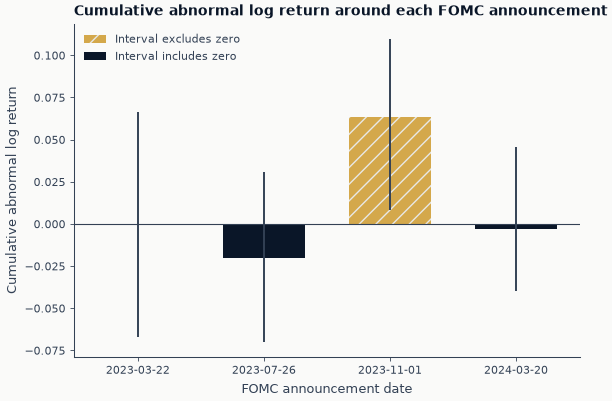

In [19]:
if not event_df.empty:
    _event_values = event_df["cum_impact"].to_numpy()
    _event_errors = np.vstack(
        [
            _event_values - event_df["cum_lower"].to_numpy(),
            event_df["cum_upper"].to_numpy() - _event_values,
        ]
    )
    _event_colors = [
        COLORS["amber"] if flag else COLORS["blue"] for flag in event_df["significant"]
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
    _event_bars = ax.bar(event_df["event_date"], _event_values, color=_event_colors, width=0.65)
    for bar, flag in zip(_event_bars, event_df["significant"], strict=True):
        bar.set_hatch("//" if flag else "")
    ax.errorbar(
        event_df["event_date"],
        _event_values,
        yerr=_event_errors,
        fmt="none",
        color=COLORS["neutral"],
        capsize=4,
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
    ax.set_ylabel("Cumulative abnormal log return")
    ax.set_xlabel("FOMC announcement date")
    ax.set_title(
        "Cumulative abnormal log return around each FOMC announcement",
        loc="left",
        color=COLORS["blue"],
        fontweight="bold",
    )
    ax.legend(
        handles=[
            Patch(facecolor=COLORS["amber"], hatch="//", label="Interval excludes zero"),
            Patch(facecolor=COLORS["blue"], label="Interval includes zero"),
        ],
        frameon=False,
    )
    show_with_alt(
        fig,
        "Bar chart with one bar per FOMC announcement date, showing the cumulative abnormal "
        "log return the BSTS counterfactual assigns to that event, each with a vertical "
        "credible-interval bar. Bars whose interval excludes zero are drawn in amber with "
        "diagonal hatching, the rest in blue, and a legend states which is which.",
    )

**Interpretation**: The FOMC event results above show whether the target ETF
(IEF by default) moved significantly after rate decisions, after constructing a
counterfactual from its controls. The causal impact estimates capture the *additional*
movement attributable to the announcement beyond what correlated assets predicted.
The uncertainty intervals, rather than a macro narrative about each date, determine
whether the model distinguishes an event response from market-wide risk.
Credible intervals that include zero indicate the model cannot distinguish the
event effect from noise.

## 5. Placebo Test Validation

Run the same analysis on 12 dates with no Fed announcement. A
"significant" cumulative impact on any of these dates means the model
is misspecified. With only 12 placebo dates the empirical rate is a
coarse diagnostic rather than a precise Type I estimate (one date in
twelve is already a rate of eight percent); we therefore report it as a
*placebo false-positive rate*, not a multiple-testing FDR.

**Caveat - macro contamination of placebo dates**: "No FOMC announcement"
is necessary but not sufficient. A clean placebo date for a Fed/bond
event study should also avoid CPI prints, payrolls, Treasury refunding
announcements, FOMC minutes, banking stress headlines, and other
macro releases that move the rates curve. The 12 dates below are not
screened for these - they are illustrative, and a publication-grade
placebo test would filter against a macro-calendar exclusion list
before computing the rate.

In [20]:
if DATA_AVAILABLE:
    placebo_results = []

    print("\n" + "=" * 60)
    print("PLACEBO TESTS")
    print("=" * 60)
    print(f"Testing {len(PLACEBO_DATES)} placebo dates with no Fed announcement.")

    for placebo_date in PLACEBO_DATES:
        result = run_event_study(
            data,
            TARGET_ETF,
            CONTROL_ETFS,
            placebo_date,
            pre_days=PRE_PERIOD_DAYS,
            post_days=POST_PERIOD_DAYS,
        )

        placebo_results.append(result)


PLACEBO TESTS
Testing 12 placebo dates with no Fed announcement.


A placebo date is only a placebo if its post-window is clear of the announcements this
notebook is studying. The windows are twenty trading days long and the FOMC meets every
six to eight weeks, so a date chosen for being on no announcement can still sit a fortnight
ahead of one, and its "false positive" would then be a true effect measured from the wrong
origin. The screen below is against `FOMC_EVENTS`, the four dates this notebook treats as
events; the wider macro calendar in the caveat above is not screened, so a window this
check calls clear is clear of those four dates and nothing more.

In [21]:
def post_window_events(date, index, post_days, event_dates):
    """FOMC dates falling inside the post-window a study of `date` would use."""
    idx = pd.DatetimeIndex(index)
    if idx.tz is not None:
        idx = idx.tz_localize(None)
    idx = idx.normalize()
    pos = idx.searchsorted(pd.to_datetime(date))
    window = idx[pos : pos + post_days]
    return [d for d in event_dates if pd.to_datetime(d) in window]

In [22]:
if DATA_AVAILABLE and placebo_results:
    _fomc_dates = [d for d, _ in FOMC_EVENTS]
    placebo_df = pd.DataFrame(
        [
            {
                "placebo_date": r["event_date"],
                "mean_daily_effect": r["impact_mean"],
                "cum_impact": r["cumulative_impact"],
                "cum_lower": r["cumulative_lower"],
                "cum_upper": r["cumulative_upper"],
                "significant": r["significant"],
                "window_events": ", ".join(
                    post_window_events(r["event_date"], data.index, POST_PERIOD_DAYS, _fomc_dates)
                ),
            }
            for r in placebo_results
        ]
    )
    placebo_df["clean_window"] = placebo_df["window_events"] == ""

    clean = placebo_df[placebo_df["clean_window"]]
    n_false_positives = int(clean["significant"].sum())
    n_total = len(clean)
    placebo_false_positive_rate = n_false_positives / n_total if n_total else None
    n_contaminated = len(placebo_df) - n_total

    if n_contaminated:
        print(
            f"{n_contaminated} of {len(placebo_df)} placebo windows contain an FOMC date "
            f"from this notebook's own event list; the rate below excludes them."
        )
    if n_total:
        print(
            f"Placebo false-positive rate: "
            f"{n_false_positives}/{n_total} = {placebo_false_positive_rate:.1%}"
        )
    else:
        print("No placebo window is clear of this notebook's FOMC dates; no rate to report.")
elif DATA_AVAILABLE:
    placebo_false_positive_rate = None
    placebo_df = pd.DataFrame()
else:
    placebo_results = []
    placebo_false_positive_rate = None
    placebo_df = pd.DataFrame()

1 of 12 placebo windows contain an FOMC date from this notebook's own event list; the rate below excludes them.
Placebo false-positive rate: 0/11 = 0.0%


A valid design should rarely produce credible intervals excluding zero on
dates without an FOMC announcement. This chart makes both the false-positive
count and the uncertainty behind each placebo estimate visible.

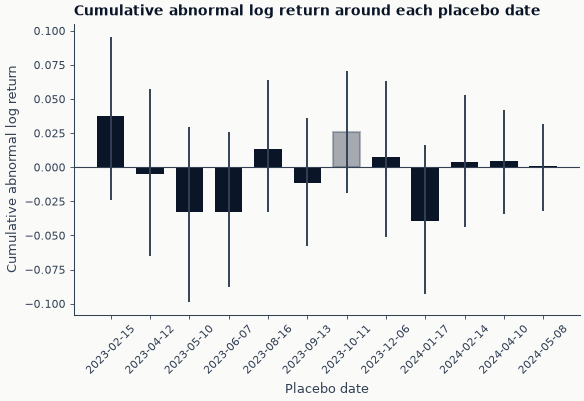

In [23]:
if not placebo_df.empty:
    _placebo_values = placebo_df["cum_impact"].to_numpy()
    _placebo_errors = np.vstack(
        [
            _placebo_values - placebo_df["cum_lower"].to_numpy(),
            placebo_df["cum_upper"].to_numpy() - _placebo_values,
        ]
    )
    _placebo_colors = [
        COLORS["negative"] if flag else COLORS["blue"] for flag in placebo_df["significant"]
    ]
    fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"], constrained_layout=True)
    _placebo_bars = ax.bar(
        placebo_df["placebo_date"], _placebo_values, color=_placebo_colors, width=0.7
    )
    for bar, flag, clean in zip(
        _placebo_bars, placebo_df["significant"], placebo_df["clean_window"], strict=True
    ):
        bar.set_hatch("//" if flag else "")
        if not clean:
            # A window holding an FOMC date is not a placebo; it stays on the chart so the
            # screen is visible, outlined rather than filled like the dates that count.
            bar.set_alpha(0.35)
            bar.set_edgecolor(COLORS["neutral"])
            bar.set_linewidth(1.5)
    ax.errorbar(
        placebo_df["placebo_date"],
        _placebo_values,
        yerr=_placebo_errors,
        fmt="none",
        color=COLORS["neutral"],
        capsize=3,
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("Cumulative abnormal log return")
    ax.set_xlabel("Placebo date")
    ax.set_title(
        "Cumulative abnormal log return around each placebo date",
        loc="left",
        color=COLORS["blue"],
        fontweight="bold",
    )
    show_with_alt(
        fig,
        "Bar chart with one bar per placebo date, showing the cumulative abnormal log return "
        "the same BSTS specification assigns to a date with no FOMC announcement, each with a "
        "vertical credible-interval bar. Bars whose interval excludes zero are drawn in red "
        "with diagonal hatching, the rest in blue, and bars for windows that contain one of "
        "the notebook's FOMC dates are faded and outlined because they are excluded from the "
        "false-positive rate.",
    )

## 6. Results Summary

In [24]:
n_events_significant = sum(1 for r in event_results if r.get("significant", False))
# The rate is over the screened windows, so the count reported beside it has to be too.
n_placebo_screened = int(placebo_df["clean_window"].sum()) if not placebo_df.empty else 0
n_placebo_significant = (
    int(placebo_df.loc[placebo_df["clean_window"], "significant"].sum())
    if not placebo_df.empty
    else 0
)

results_summary = {
    "library_used": "tfcausalimpact",
    "target_etf": TARGET_ETF,
    "control_etfs": CONTROL_ETFS,
    "pre_period_days": PRE_PERIOD_DAYS,
    "post_period_days": POST_PERIOD_DAYS,
    "events_analyzed": len(event_results),
    "events_significant": n_events_significant,
    "placebo_tests_run": len(placebo_results),
    "placebo_windows_clear_of_fomc": n_placebo_screened,
    "placebo_false_positives": n_placebo_significant,
    "placebo_false_positive_rate": placebo_false_positive_rate,
    "spillover_warnings": spillover_warnings if "spillover_warnings" in dir() else [],
}

pfpr_str = (
    f"{placebo_false_positive_rate:.1%}" if placebo_false_positive_rate is not None else "N/A"
)

In [25]:
print("\n" + "=" * 60)
print("SUMMARY: FED ANNOUNCEMENT BSTS EVENT STUDY")
print("=" * 60)

print(f"""
CONFIGURATION:
  Pre-period: {PRE_PERIOD_DAYS} trading days (~3 months)
  Post-period: {POST_PERIOD_DAYS} trading days (~1 month)
  Target: {TARGET_ETF}
  Controls: {", ".join(CONTROL_ETFS)}

VALIDATION:
  Spillover check: {"FLAG: " + str(spillover_warnings) if spillover_warnings else "No interval-based flag"}
  Placebo tests: {len(placebo_results)} run, {n_placebo_screened} clear of the FOMC dates
  Placebo false-positive rate: {pfpr_str}

EVENT RESULTS:
  Events analyzed: {len(event_results)}
  Significant impacts: {n_events_significant}

INTERPRETATION GUIDANCE:
  - Interpret event results only when placebo false positives are rare
    and no interval-based control spillover is detected
  - Passing these diagnostics does not prove that controls are unaffected
  - Credible intervals capture posterior uncertainty
  - Consider sensitivity to window length choices
""")


SUMMARY: FED ANNOUNCEMENT BSTS EVENT STUDY

CONFIGURATION:
  Pre-period: 60 trading days (~3 months)
  Post-period: 20 trading days (~1 month)
  Target: IEF
  Controls: VEA, EFA, DBC

VALIDATION:
  Spillover check: No interval-based flag
  Placebo tests: 12 run, 11 clear of the FOMC dates
  Placebo false-positive rate: 0.0%

EVENT RESULTS:
  Events analyzed: 4
  Significant impacts: 1

INTERPRETATION GUIDANCE:
  - Interpret event results only when placebo false positives are rare
    and no interval-based control spillover is detected
  - Passing these diagnostics does not prove that controls are unaffected
  - Credible intervals capture posterior uncertainty
  - Consider sensitivity to window length choices



## Key Takeaways

1. **BSTS constructs a counterfactual** from pre-event target-control
   relationships and reports the post-event gap with posterior uncertainty.
2. **The cumulative estimand has return units** because the model uses daily log
   returns; summing post-period point effects yields cumulative abnormal log return.
3. **Placebo and control-as-target tests are diagnostics, not proofs**. Passing
   their interval rules does not establish that global controls are unaffected.
4. **Daily timing remains a limitation**. A close-to-close event-day return mixes
   trading before and after the afternoon announcement.
5. **A placebo date is only a placebo if its window is one.** The dates here are screened
   against the four announcements this notebook studies, and against nothing else; CPI
   prints, payrolls and refunding announcements still sit inside some of these windows,
   and window length remains untested at a single pre and post setting.

Continue with `07_tigramite_time_series` for time-series causal discovery. See
Section 15.5 for BSTS identification assumptions and event-study interpretation.